# SNEC exploration
author: [Mathieu Renzo](mailto:mrenzo@arizona.edu)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from SNEC_output_parser import SNEC_output_parser, read_SNEC_hdf5
from plots import plot_LC
from MESAreader import get_src_col, Msun
%load_ext autoreload
%autoreload 2

Hardcoded some constants
None


In [2]:
def get_fields(data):
    """Return only the spatial field snapshots (modeflag=1)."""
    return {k.split("/", 1)[1]: v for k, v in data.items() if k.startswith("fields/")}


def get_scalars(data):
    """Return only the time-series scalars (modeflag=2)."""
    return {k.split("/", 1)[1]: v for k, v in data.items() if k.startswith("scalars/")}


In [3]:
root = "/home/mrenzo/Documents/Research/Projects/TARDIS_connector_2025/SNEC/output/large_net/"  #/home/mrenzo/Documents/Research/codes/SNEC-1.01/output/large_net/" #
file_list = glob.glob(root+"*")
for f in file_list: print(f.split('/')[-1])
mesa_pfile = "../input/last_profile.data"
mesa_src, mesa_col = get_src_col(mesa_pfile)


magnitudes.dat
velshock_index.dat
density_profile.dat
delta_mass_initial.dat
H_init_frac.dat
Ni_init_frac.dat
info.dat
C_init_frac.dat
metallicity_init.dat
parameters
He_init_frac.dat
rad_initial.dat
mass_initial.dat
conservation.dat
press_initial.dat
cache
O_init_frac.dat
opacity_floor.dat
output.h5
rho_initial.dat


/tmp/ipykernel_153255/3762083390.py:10: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t, np.log10(L), label="tot")
/tmp/ipykernel_153255/3762083390.py:11: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t, np.log10(Lni56), ls='--', c='k', label="ni56")


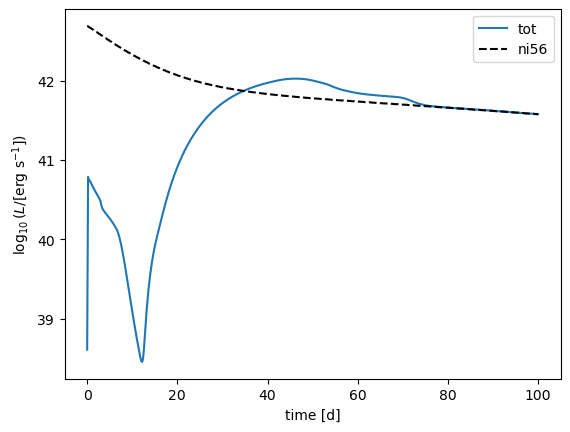

In [4]:
fig, ax = plt.subplots()
try:
    plot_LC(root+'/lum_observed.dat', ax=ax)
except:
    data = read_SNEC_hdf5(root+"output.h5")
    mass = data["fields/mass"][0,1]
    t = data["scalars/time"]/86400.
    L = data["scalars/lum_observed"]
    Lni56 = data["scalars/Ni_total_luminosity"]
    ax.plot(t, np.log10(L), label="tot")
    ax.plot(t, np.log10(Lni56), ls='--', c='k', label="ni56")
ax.set_xlabel(r"time [d]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{[erg\ s^{-1}]})$")
ax.legend()

# Ni deposition function

In [5]:
data = read_SNEC_hdf5(root+"output.h5")
for key, val in sorted(data.items()):
    val = np.atleast_1d(val)
    print(f"{key:<40}  {str(val.shape):<20}  {val.dtype}")

fields/E_shell                            (1265, 511)           float64
fields/H_1                                (1265, 511)           float64
fields/H_2                                (1265, 511)           float64
fields/He_1                               (1265, 511)           float64
fields/He_2                               (1265, 511)           float64
fields/He_3                               (1265, 511)           float64
fields/Ni_deposit_function                (1265, 511)           float64
fields/Q                                  (1265, 511)           float64
fields/cs2                                (1265, 511)           float64
fields/delta_time                         (1265, 511)           float64
fields/eps                                (1265, 511)           float64
fields/free_electron_frac                 (1265, 511)           float64
fields/kappa                              (1265, 511)           float64
fields/kappa_table                        (1265, 511)           

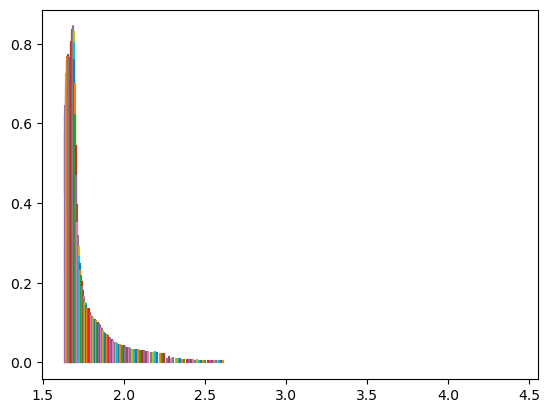

In [6]:
def plot_Ni_deposition(ni_deposit_function, ax=None, **kwargs):
    data = SNEC_output_parser(ni_deposit_function)
    times = np.array(list(data.keys())) # in sec

    # to map on radius
    # data_r = SNEC_output_parser(mass_file)
    if not ax:
        fig, ax = plt.subplots()
    for i, t in enumerate(times):
        # ax.plot(data[t][:, 0]/2e33, data[t][:, 1]/1e8)
        ax.plot(data[t][:, 0]/Msun, data[t][:, 1], **kwargs)

# test
# ni_deposit_function = root+"Ni_deposit_function.xg"
# plot_Ni_deposition(ni_deposit_function)


def plot_Ni_deposition_hdf5(output, ax=None, **kwargs):
    data = read_SNEC_hdf5(output)
    if not ax:
        fig, ax = plt.subplots()
    times = data["scalars/time"]
    m = data["fields/mass"]
    ni_deposit = data["fields/Ni_deposit_function"]
    for i, t in enumerate(times):
        ax.plot(m[i]/Msun, ni_deposit[i], **kwargs)


data = root+"output.h5"
plot_Ni_deposition_hdf5(data, ax=None)
        

# N initial mass distribution

0.06 Msun of Ni56


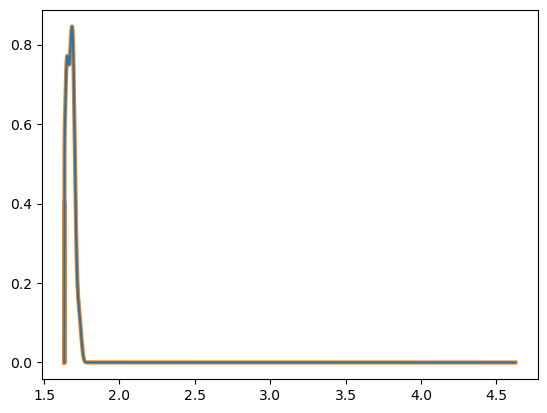

In [7]:
def plot_Ni_init(Ni_init_frac, mass_file, ax=None, **kwargs):
    src = np.genfromtxt(Ni_init_frac)
    try:
        mass = SNEC_output_parser(mass_file)[0][:,1]/Msun    
    except:
        data = read_SNEC_hdf5(root+"output.h5")
        mass = data["fields/mass"][:,1]/Msun
    if not ax:
        fig, ax = plt.subplots()
    ax.plot(mass ,src[:, 1], **kwargs)
    print(f"{np.sum(src[:, 1]*np.diff(mass, append=0)):.2f} Msun of Ni56")
    return ax

Ni_init_frac = root+"Ni_init_frac.dat"
mass_file = root+"mass.xg"
ni56 = mesa_src[:, mesa_col.index("ni56")]
m = mesa_src[:, mesa_col.index("mass")]
ax = plot_Ni_init(Ni_init_frac, mass_file, ax=None)
ax.plot(m, ni56, lw=3, zorder=0)


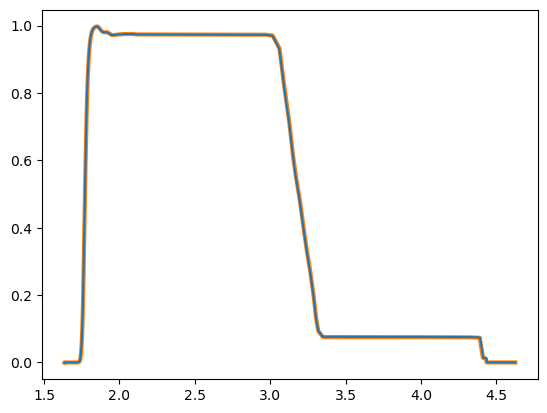

In [8]:
def plot_O_init(O_init_frac, mass_file, ax=None, **kwargs):
    src = np.genfromtxt(O_init_frac)
    try:
        mass = SNEC_output_parser(mass_file)[0][:,1]/Msun    
    except:
        data = read_SNEC_hdf5(root+"output.h5")
        mass = data["fields/mass"][:,1]/Msun
    if not ax:
        fig, ax = plt.subplots()
    ax.plot(mass ,src[:, 1], **kwargs)
    return ax

O_init_frac = root+"O_init_frac.dat"
mass_file = root+"mass.xg"
ax = plot_O_init(O_init_frac, mass_file, ax=None)
o16 = mesa_src[:, mesa_col.index("o16")]
m = mesa_src[:, mesa_col.index("mass")]
ax.plot(m, o16, lw=3, zorder=0)



(1e+17, 4e+18)

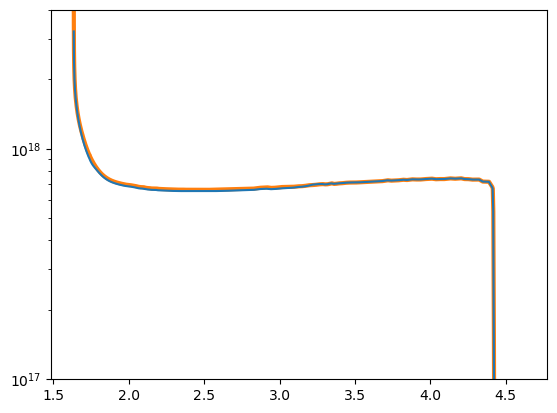

In [9]:
def plot_pressure_init(pressure_init_frac, mass_file, ax=None, **kwargs):
    try:
        src = np.genfromtxt(pressure_init_frac)
        mass = SNEC_output_parser(mass_file)[0][:,1]/Msun    
    except:
        data = read_SNEC_hdf5(root+"output.h5")
        mass = data["fields/mass"][:,1]/Msun
        press = data["fields/press"][:,0]
    if not ax:
        fig, ax = plt.subplots()
    ax.plot(mass, press, **kwargs)
    return ax

pressure_init_frac = root+"press_initial.dat"
mass_file = root+"mass.xg"
ax = plot_pressure_init(pressure_init_frac, mass_file, ax=None, zorder=1)
P = 10.**mesa_src[:, mesa_col.index("logP")]
m = mesa_src[:, mesa_col.index("mass")]
ax.plot(m, P, lw=3, zorder=0)
ax.set_yscale('log')
ax.set_ylim(1e17, 4e18)

Text(0, 0.5, '$\\rho\\ [ \\mathrm{g\\ cm^{-3}}]$')

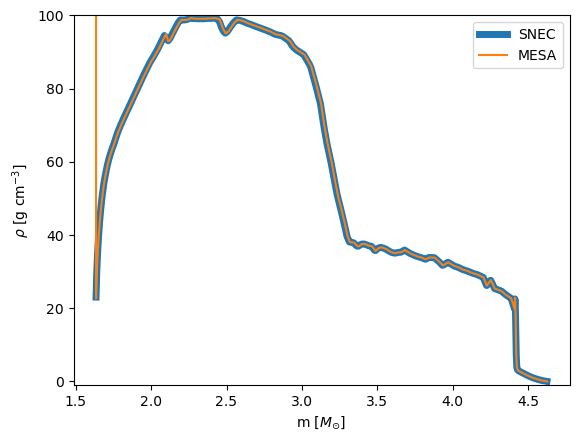

In [10]:
def plot_density_init(density_init_frac, mass_file, ax=None, **kwargs):
    src = np.genfromtxt(density_init_frac)
    try:
        mass = SNEC_output_parser(mass_file)[0][:,1]/Msun    
    except:
        data = read_SNEC_hdf5(root+"output.h5")
        mass = data["fields/mass"][:,1]/Msun
    if not ax:
        fig, ax = plt.subplots()
    ax.plot(mass ,src[:, 1], **kwargs)
    return ax

density_init_frac = root+"rho_initial.dat"
mass_file = root+"mass.xg"
ax = plot_density_init(density_init_frac, mass_file, ax=None,
                       lw=5, label="SNEC")
m = mesa_src[:, mesa_col.index("mass")]
rho = 10**(mesa_src[:, mesa_col.index("logRho")])
# print(m, rho)
ax.plot(m, rho, label="MESA")
ax.legend()
# ax.set_yscale('log')
ax.set_ylim(ymax=1e2, ymin=-1)
ax.set_xlabel(r"m [$M_{\odot}$]")
ax.set_ylabel(r"$\rho\ [ \mathrm{g\ cm^{-3}}]$")

In [ ]:
vel_file = root+"vel.xg"
data = SNEC_output_parser(vel_file)
fig, ax = plt.subplots()
ax.scatter(data[0][:, 0]/Msun,
           data[0][:, 1]/1e5, # km/s
           label="SNEC")
v = mesa_src[:, mesa_col.index("velocity")]/1e5 # km/s
print(min(v))
ax.scatter(m, v, label="MESA", lw=3, s=80,zorder=0, c="C1")
ax.set_yscale("symlog")
ax.legend()
ax.set_xlabel("mass [Msun]")
ax.set_ylabel("velocity [km/s]")

52


Text(0, 0.5, 'velocity [km/s]')

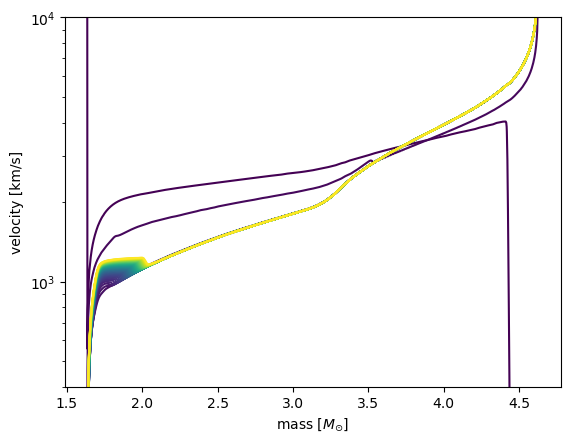

In [12]:
def plot_v_m(output, ax=None, **kwargs):
    data = read_SNEC_hdf5(output)
    if not ax:
        fig, ax = plt.subplots()
    times = data["scalars/time"]
    m = data["fields/mass"]/Msun
    v= data["fields/vel"]/1e5
    colors = plt.cm.viridis(np.linspace(0,1,len(times[::10])))
    print(len(colors))
    for i, t in enumerate(times[::10]):
        ax.plot(m[:,i], v[:,i], color=colors[i])
    return ax

ax = plot_v_m(root+"output.h5")
ax.set_yscale('log')
ax.set_ylim(4e2, 1e4)
# ax.set_xlim(1, 1.25)
ax.set_xlabel(r"mass $[M_{\odot}]$")
ax.set_ylabel(r"velocity [km/s]")


52


(100000000000.0, 1000000000000000.0)

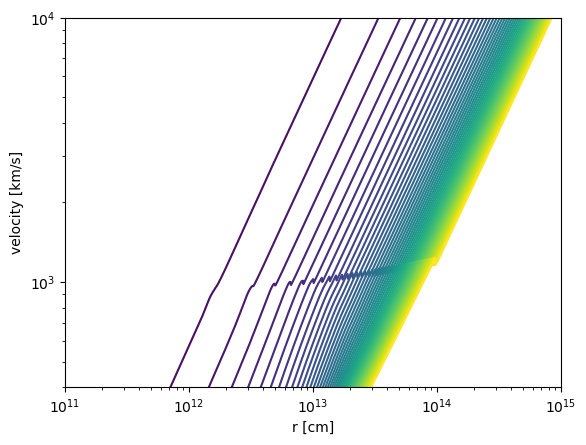

In [13]:
def plot_v_r(output, ax=None, **kwargs):
    data = read_SNEC_hdf5(output)
    if not ax:
        fig, ax = plt.subplots()
    times = data["scalars/time"]
    r = data["fields/radius"]
    v= data["fields/vel"]/1e5
    colors = plt.cm.viridis(np.linspace(0,1,len(times[::10])))
    print(len(colors))
    for i, t in enumerate(times[::10]):
        ax.plot(r[:,i], v[:,i], color=colors[i])
    return ax

ax = plot_v_r(root+"output.h5")
ax.set_yscale('log')
ax.set_ylim(4e2, 1e4)
ax.set_xlim(1, 1.25)
ax.set_xlabel(r"r [cm]")
ax.set_ylabel(r"velocity [km/s]")
ax.set_xscale('log')
ax.set_xlim(1e11, 1e15)

In [14]:

data = read_SNEC_hdf5(root+"/output.h5")


0.0


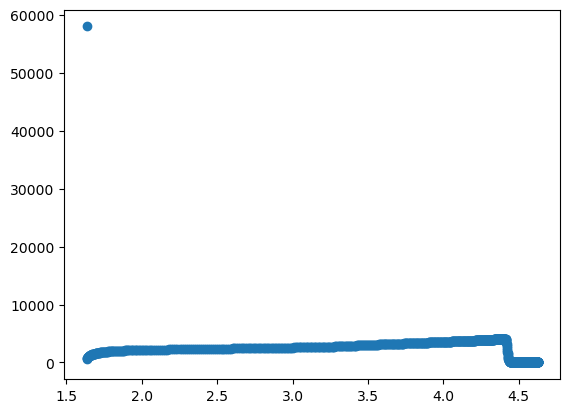

In [15]:
fig, ax = plt.subplots()
times = data["scalars/time"]
m = data["fields/mass"]/Msun
v= data["fields/vel"]/1e5
print(times[0])
ax.scatter(m[:,0], v[:,0])


In [16]:
print(np.shape(m))

(1265, 511)
